## Human in the Loop — LangGraph
Pausing workflows for human approval · interrupt_before · MemorySaver checkpointing

### Definition
Human in the Loop is a LangGraph feature that pauses an agent workflow at a specified node and waits for explicit human feedback or approval before continuing execution.

### Series context
Prerequisites already covered: different workflow types, debugging LangGraph apps, chatbots, Pydantic integration, and ReAct agents. HITL builds directly on top of all of these.


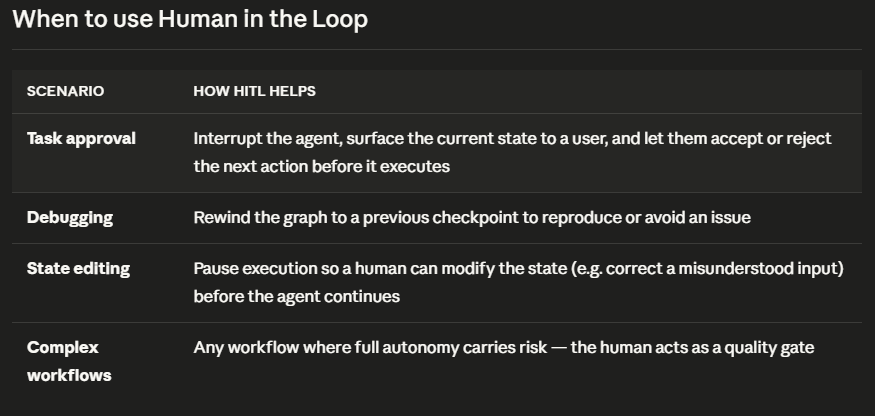

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_nvidia_ai_endpoints import ChatNVIDIA

os.environ['NVIDIA_API_KEY'] = os.getenv('NVIDIA_API_KEY')
os.environ['LANGSMITH_API_KEY'] = os.getenv('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = "true"
os.environ['LANGCHAIN_PROJECT'] = "Human in the Loop"

llm = ChatNVIDIA(
  model="openai/gpt-oss-20b",
  api_key=os.getenv('NVIDIA_API_KEY'), 
  temperature=1,
  top_p=1,
  max_completion_tokens=4096,
)

In [2]:
### Custom tools
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a by b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools = [add,multiply,divide]

## Integrate tools with llm
llm_with_tools=llm.bind_tools(tools)
llm_with_tools

RunnableBinding(bound=ChatNVIDIA(output_version=None, profile={}, base_url='https://integrate.api.nvidia.com/v1', model='openai/gpt-oss-20b', temperature=1.0, max_tokens=4096, top_p=1.0, default_headers={}, model_kwargs={}), kwargs={'tools': [{'type': 'function', 'function': {'name': 'add', 'description': 'Adds a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'multiply', 'description': 'Multiply a and b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'integer'}}, 'required': ['a', 'b'], 'type': 'object'}}}, {'type': 'function', 'function': {'name': 'divide', 'description': 'Divide a by b.', 'parameters': {'properties': {'a': {'description': 'first int', 'type': 'integer'}, 'b': {'description': 'second int', 'type': 'int

c:\Users\singh\OneDrive\Desktop\Generative-AI-using-LangGraph\LangGraphEnv\Lib\site-packages\langgraph\checkpoint\serde\encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


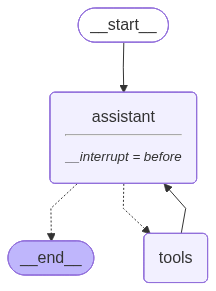

In [3]:
### WWorkflow with Langgraph
from IPython.display import Image, display

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import MessagesState
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import tools_condition, ToolNode
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage

## system Message
sys_msg = SystemMessage(content=(
        "You MUST use the provided add, multiply, and divide tools "
        "for ALL arithmetic operations, no matter how simple. "
        "Never compute math yourself."
    ))

## node definition
def assistant(state:MessagesState):
    return {"messages":[llm_with_tools.invoke([sys_msg] + state["messages"])]}

#Graph
builder=StateGraph(MessagesState)

## Define nodes: 
builder.add_node("assistant",assistant)
builder.add_node("tools",ToolNode(tools))

## Define the Edges

builder.add_edge(START,"assistant")
builder.add_conditional_edges(
    "assistant",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,

)
builder.add_edge("tools","assistant")

memory=MemorySaver()

### human in the loop
graph=builder.compile(interrupt_before=["assistant"],checkpointer=memory)

# Show
display(Image(graph.get_graph().draw_mermaid_png()))


In [4]:
thread={"configurable":{"thread_id":"123"}}
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

In [5]:
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [6]:
state=graph.get_state(thread)
state.next

('assistant',)

In [7]:
state

StateSnapshot(values={'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='fbd00c29-1c63-4062-96ac-8f53f66daa45')]}, next=('assistant',), config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f14a7ee-9445-6741-8000-a1f8ef42990f'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-05-08T01:40:36.510086+00:00', parent_config={'configurable': {'thread_id': '123', 'checkpoint_ns': '', 'checkpoint_id': '1f14a7ee-9443-6168-bfff-85d3ee69f012'}}, tasks=(PregelTask(id='4dbc40c3-0847-fd96-79d2-d473757b6641', name='assistant', path=('__pregel_pull', 'assistant'), error=None, interrupts=(), state=None, result=None),), interrupts=())

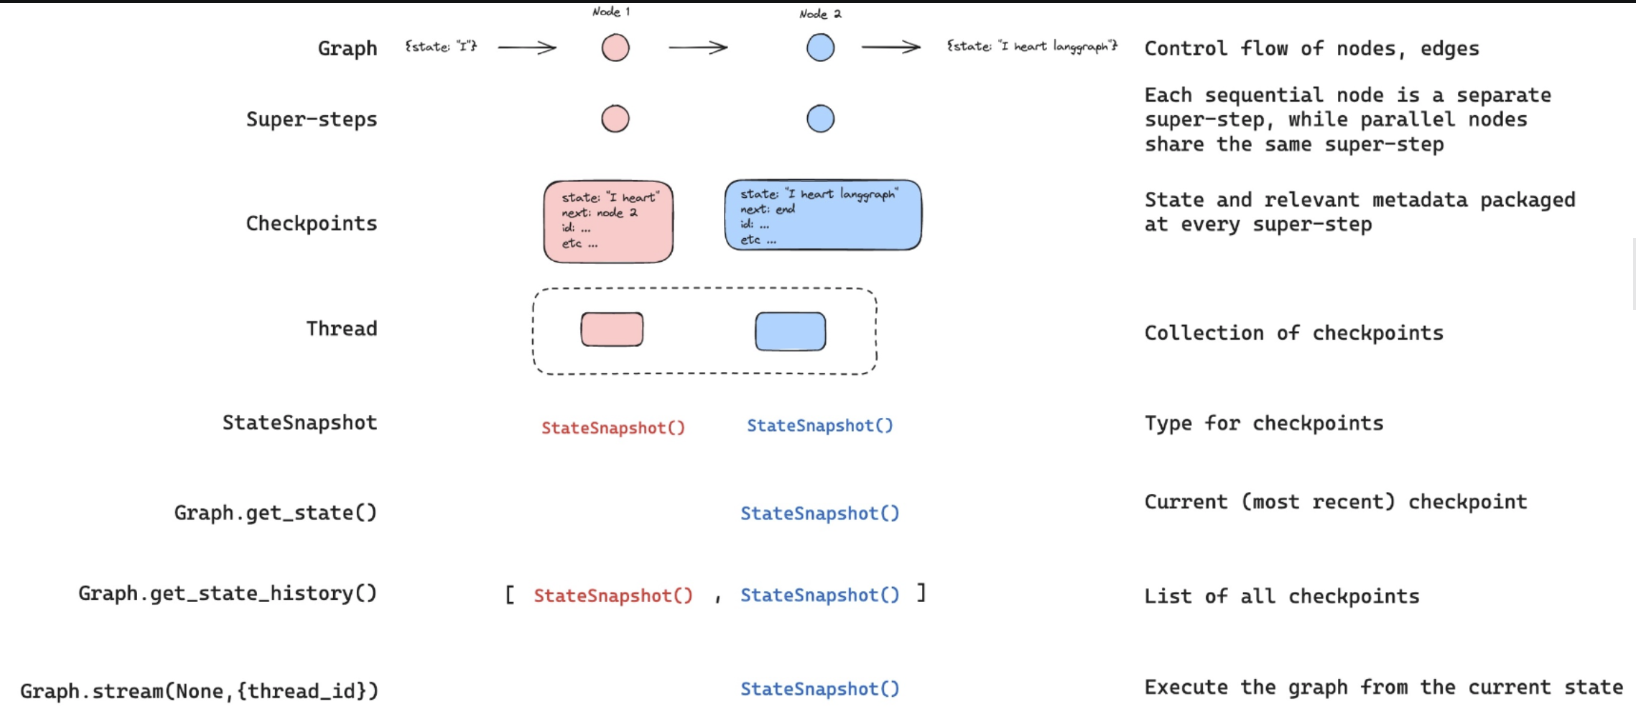

In [8]:
## Continue the execution to Assistant
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-a6227de57721efe9)
 Call ID: chatcmpl-tool-a6227de57721efe9
  Args:
    a: 2
    b: 3
================================= Tool Message =================================
Name: multiply

6


In [9]:
state=graph.get_state(thread)
state.next

('assistant',)

In [10]:
## Continue the execution of Assistant and then end
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

6
================================== Ai Message ==================================

6


## Edit Human Feedback

In [11]:
initial_input={"messages":HumanMessage(content="Multiply 2 and 3")}

thread={"configurable":{"thread_id":"1"}}
for event in graph.stream(initial_input,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3


In [13]:
graph.get_state(thread)
state.next

('assistant',)

In [14]:
graph.update_state(thread, {"messages" : [HumanMessage(content= "No, Please multiply 15 and 6")]})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f14a7f9-6586-65f3-8001-5ef502370aa4'}}

In [17]:
graph.get_state(thread).values

{'messages': [HumanMessage(content='Multiply 2 and 3', additional_kwargs={}, response_metadata={}, id='9e295e10-0ce7-4c3d-b829-3352725d0af6'),
  HumanMessage(content='No, Please multiply 15 and 6', additional_kwargs={}, response_metadata={}, id='b9ef332e-39c9-4d03-8cb0-1b29d3ca7b33')]}

In [18]:
for event in graph.stream(None,thread,stream_mode="values"):
    event['messages'][-1].pretty_print()

================================ Human Message =================================

No, Please multiply 15 and 6
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-a1ee1aaf2a31a9d5)
 Call ID: chatcmpl-tool-a1ee1aaf2a31a9d5
  Args:
    a: 15
    b: 6
================================= Tool Message =================================
Name: multiply

90


In [19]:
for event in graph.stream(None, thread, stream_mode="values"):
    event['messages'][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

90
================================== Ai Message ==================================

The result of multiplying 15 by 6 is **90**.


## Workflow will Wait for the User Input

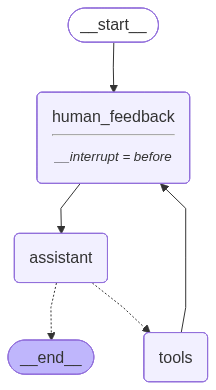

In [ ]:
# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with performing arithmetic on a set of inputs.")


## Human feedback node

def human_feedback(state:MessagesState):
    pass

### Assistant node
def assistant(state:MessagesState):
    return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

# Graph
builder = StateGraph(MessagesState)

# Define nodes: these do the work
builder.add_node("assistant", assistant)
builder.add_node("tools", ToolNode(tools))
builder.add_node("human_feedback", human_feedback)


## Define the edges
builder.add_edge(START,"human_feedback")
builder.add_edge("human_feedback","assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools","human_feedback")

memory=MemorySaver()
graph=builder.compile(interrupt_before=["human_feedback"],checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# Input
initial_input = {"messages": "Multiply 2 and 3"}

# Thread
thread = {"configurable": {"thread_id": "5"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()


## get user input
user_input=input("Tell me how you want to update the state:")
graph.update_state(thread,{"messages":user_input},as_node="human_feedback")


# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================ Human Message =================================

Multiply 2 and 3
================================ Human Message =================================

9 * 20
================================== Ai Message ==================================
Tool Calls:
  multiply (chatcmpl-tool-8e0c8fcc119e8a72)
 Call ID: chatcmpl-tool-8e0c8fcc119e8a72
  Args:
    a: 9
    b: 20
================================= Tool Message =================================
Name: multiply

180


In [23]:
# Continue the graph execution
for event in graph.stream(None, thread, stream_mode="values"):
    event["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: multiply

180
================================== Ai Message ==================================

- Multiply 2 × 3 = **6**

- Multiply 9 × 20 = **180**
